In [1]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

In [6]:
adfs = {}
ldfs = {}
for file in Path("../runs/test/64_cells/lattices/").iterdir():
    time = int(file.name.replace(".parquet", ""))
    ldfs[time] = pl.read_parquet(file)
    adfs[time] = pl.read_parquet(str(file).replace("lattices", "act_lattices"))

In [22]:
_neighs = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]


def inbounds(x, y, w, h):
    if x < 0:
        return False
    if x > w - 1:
        return False
    if y < 0:
        return False
    if y > h - 1:
        return False
    return True


def neighs(x, y, w, h):
    return filter(lambda pos: inbounds(pos[0], pos[1], w, h), map(lambda pos: (pos[0] + x, pos[1] + y), _neighs))


# This is not quite what ava did.
# Try:
#   Using the geom mean of each pos
#   Taking the average per neighbour of the entire cell (use two NCELLS X NCELLS matrices to calculate the averages)
def act_sum(latdf, actdf):
    label = []
    actv = []
    for i in range(0, latdf.shape[0]):
        for j in range(0, latdf.shape[1]):
            for n in neighs(i, j, latdf.shape[0], latdf.shape[1]):
                interface = sorted((latdf[i, j], latdf[n[0], n[1]]))
                if not interface[0].isnumeric():
                    continue
                act = (actdf[i, j] + actdf[n[0], n[1]]) / 2
                if interface[1].isnumeric() and int(interface[0]) != int(interface[1]):
                    label.append(0)
                    actv.append(act)
                elif interface[1] == "m":
                    label.append(1)
                    actv.append(act)
    return pl.DataFrame({
        "label": label,
        "act": actv
    })

In [23]:
asdf = act_sum(ldfs[750000], adfs[750000])

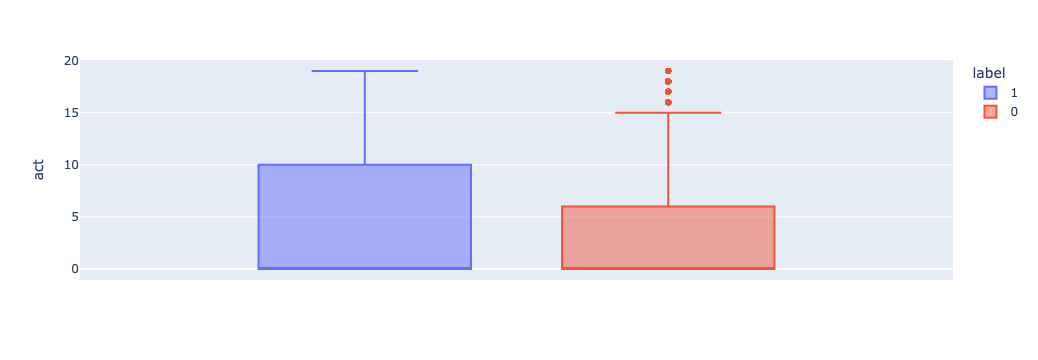

In [24]:
px.box(asdf, y="act", color="label")

In [11]:
asdf.group_by("label").mean()

label,act
i64,f64
0,3.522195
1,2.272909
